# 📈 Forecasting UK Real Estate Prices with ARIMA & Prophet

This notebook explores time series forecasting on UK property prices using:
- **ARIMA (AutoRegressive Integrated Moving Average)**
- **Prophet (Facebook's library for forecasting)**

We'll use the average monthly `Log_Price` from the cleaned macroeconomic dataset.

In [11]:
# ✅ Setup
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from prophet.plot import plot_plotly
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [12]:
from google.cloud import storage
import pandas as pd
import os

# Cấu hình
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "gcp-key.json"
bucket_name = "boothill2001-dataset"
gcs_path = "uk_property_data/processed/merged_real_estate_macro.parquet"
local_path = "../data/merged_real_estate_macro.parquet"

# Tải từ GCS nếu chưa có
if not os.path.exists(local_path):
    os.makedirs("../data", exist_ok=True)
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(gcs_path)
    blob.download_to_filename(local_path)
    print(f"✅ Downloaded from GCS → {local_path}")

# Load parquet
df = pd.read_parquet(local_path)
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))


In [13]:
# 📊 Group by monthly average price
df_grouped = df.groupby('Date')['Log_Price'].mean().reset_index()
df_grouped.columns = ['ds', 'y']
df_grouped.tail()

,ds,y
335,2022-12-01,12.542704
336,2023-01-01,12.515909
337,2023-02-01,12.485134
338,2023-03-01,12.480143
339,2023-04-01,12.485555


## 🔮 Forecast with Prophet

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdm_ft7r5/7c_9alc1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdm_ft7r5/juxiwo2l.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=47302', 'data', 'file=/tmp/tmpdm_ft7r5/7c_9alc1.json', 'init=/tmp/tmpdm_ft7r5/juxiwo2l.json', 'output', 'file=/tmp/tmpdm_ft7r5/prophet_model0tpkwqmg/prophet_model-20250417073101.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
07:31:01 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:31:01 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


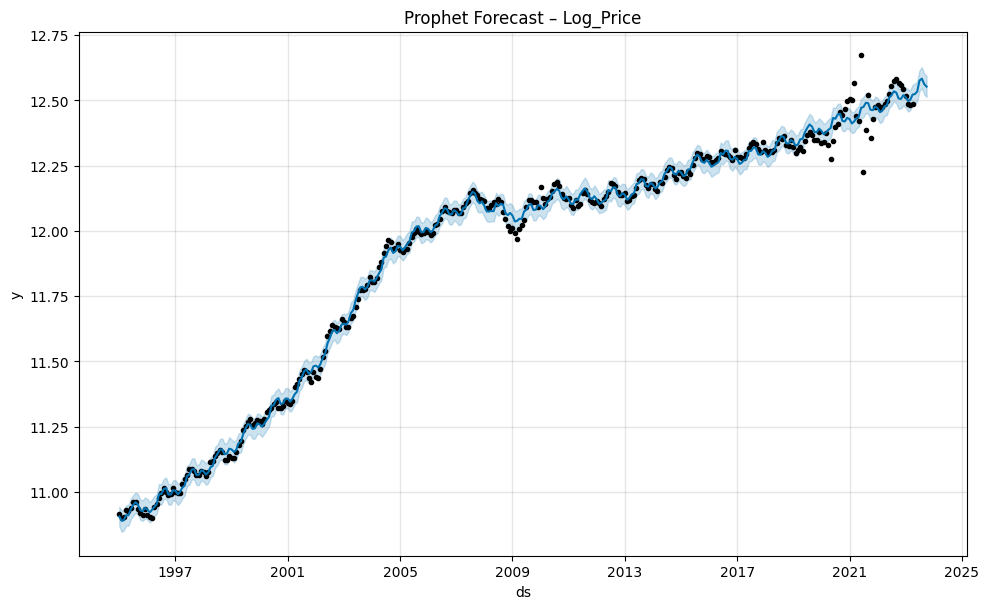

In [14]:
# ✅ Prophet Forecast
model = Prophet()
model.fit(df_grouped)
future = model.make_future_dataframe(periods=6, freq='M')
forecast = model.predict(future)
fig = model.plot(forecast)
plt.title('Prophet Forecast – Log_Price');

## 🔁 Forecast with ARIMA

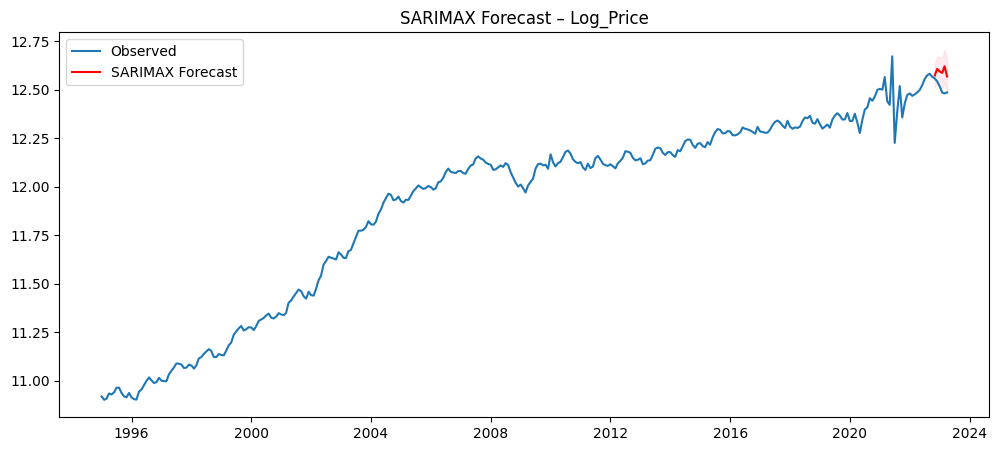

In [15]:
# 📈 SARIMAX Forecast – without pmdarima
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# 🧱 Load data
df = pd.read_parquet('../data/merged_real_estate_macro.parquet')
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
df_monthly = df.groupby('Date')['Log_Price'].mean()

# 📊 Train-Test Split (last 6 months for prediction)
train = df_monthly[:-6]
test = df_monthly[-6:]

# 🔁 Fit SARIMAX model (manual params)
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit()

# 🔮 Forecast
forecast = results.get_forecast(steps=6)
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# 📈 Plot
plt.figure(figsize=(12,5))
plt.plot(df_monthly.index, df_monthly, label="Observed")
plt.plot(pred_mean.index, pred_mean, label="SARIMAX Forecast", color='red')
plt.fill_between(pred_mean.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.title("SARIMAX Forecast – Log_Price")
plt.legend()
plt.show()


🔧 📊 Overlay Prophet vs ARIMA vs True Price and 🧪 📐 Tính RMSE / MAE cho cả 2 model

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdm_ft7r5/3ghgxed0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdm_ft7r5/8myfckh3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=36648', 'data', 'file=/tmp/tmpdm_ft7r5/3ghgxed0.json', 'init=/tmp/tmpdm_ft7r5/8myfckh3.json', 'output', 'file=/tmp/tmpdm_ft7r5/prophet_model0ky_you7/prophet_model-20250417073749.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
07:37:49 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:37:49 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


🔍 Prophet - MAE: 0.0582 | RMSE: 0.065
🔍 ARIMA   - MAE: 0.08 | RMSE: 0.0885


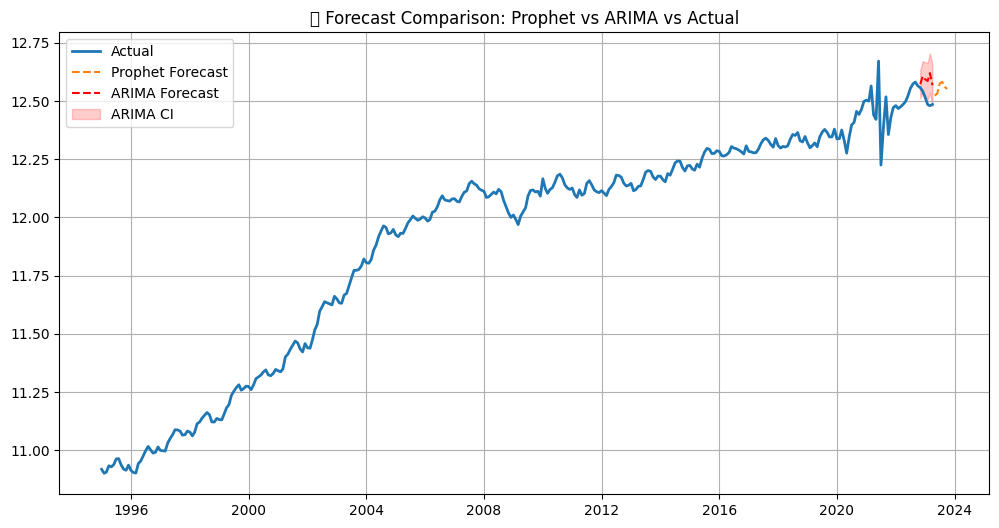

In [18]:
# 🎯 Overlay Prophet vs ARIMA vs Actual
# Prophet forecast
model_prophet = Prophet()  # Create a new Prophet model instance
model_prophet.fit(df_grouped) # Fit the model again
forecast_prophet = model_prophet.predict(future) # Use the Prophet model for prediction
prophet_pred = forecast_prophet[['ds', 'yhat']].set_index('ds')['yhat'].tail(6)

# ARIMA forecast (đã có sẵn)
arima_pred = pred_mean

# Dữ liệu thực tế
actual = df_grouped.set_index('ds')['y'].tail(6)

# 🔢 Tính lỗi
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_prophet = mean_absolute_error(actual, prophet_pred)
rmse_prophet = mean_squared_error(actual, prophet_pred) ** 0.5

mae_arima = mean_absolute_error(actual, arima_pred)
rmse_arima = mean_squared_error(actual, arima_pred) ** 0.5

print("🔍 Prophet - MAE:", round(mae_prophet, 4), "| RMSE:", round(rmse_prophet, 4))
print("🔍 ARIMA   - MAE:", round(mae_arima, 4), "| RMSE:", round(rmse_arima, 4))


plt.figure(figsize=(12,6))
plt.plot(df_grouped['ds'], df_grouped['y'], label='Actual', linewidth=2)
plt.plot(prophet_pred.index, prophet_pred, label='Prophet Forecast', linestyle='--')
plt.plot(arima_pred.index, arima_pred, label='ARIMA Forecast', linestyle='--', color='red')
plt.fill_between(arima_pred.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='red', alpha=0.2, label='ARIMA CI')
plt.title('📊 Forecast Comparison: Prophet vs ARIMA vs Actual')
plt.legend()
plt.grid(True)
plt.show()
